## 1. Load Dataset and Import libraries

In [1]:
import os
from pathlib import Path

import joblib
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / "data" / "processed" / "splits").exists():
            return candidate
    if (cwd / "Topic_13_Retail_Store_Sales_Time_Series").exists():
        return cwd / "Topic_13_Retail_Store_Sales_Time_Series"
    raise FileNotFoundError("Could not locate project root from current working directory.")


BASE = find_project_root()
SPLIT_DIR = BASE / "data" / "processed" / "splits"

X_train = pd.read_csv(SPLIT_DIR / "train_features.csv")
y_train = pd.read_csv(SPLIT_DIR / "train_target.csv")
X_val = pd.read_csv(SPLIT_DIR / "val_features.csv")
y_val = pd.read_csv(SPLIT_DIR / "val_target.csv")
X_test = pd.read_csv(SPLIT_DIR / "test_features.csv")
y_test = pd.read_csv(SPLIT_DIR / "test_target.csv")
y_val_orig = pd.read_csv(SPLIT_DIR / "val_target_original.csv")

X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

y_test_orig = pd.DataFrame({"sales": np.expm1(y_test["sales_log"])})

xgb_best_model = joblib.load(BASE / "notebooks" / "08_forecasting" / "xgb_best_model.pkl")
lgb_best_model = joblib.load(BASE / "notebooks" / "08_forecasting" / "lgb_best_model.pkl")


def rmsle_from_log(y_true, pred_log):
    y_true = np.clip(np.asarray(y_true, dtype=float), 0, None)
    y_pred = np.clip(np.expm1(np.asarray(pred_log, dtype=float)), 0, None)
    return np.sqrt(mean_squared_log_error(y_true, y_pred))


def build_summary_rows():
    return [
        {
            "Approach": "LightGBM (tuned)",
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], lgb_val_pred), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], lgb_test_pred), 6),
        },
        {
            "Approach": "XGBoost (tuned)",
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], xgb_val_pred), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], xgb_test_pred), 6),
        },
    ]


In [2]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    le = LabelEncoder()
    combined = pd.concat([X_train[col], X_val[col], X_test[col]], ignore_index=True).astype(str)
    le.fit(combined)

    X_train[col] = le.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col] = le.transform(X_val[col].astype(str)).astype(np.int32)
    X_test[col] = le.transform(X_test[col].astype(str)).astype(np.int32)

    label_encoders[col] = le

rest = X_train.select_dtypes(include=["object"]).columns.tolist()
if rest:
    raise ValueError(f"Still has object columns after encoding: {rest}")

print(f"Encoded {len(object_cols)} categorical columns.")
print(f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")


Encoded 6 categorical columns.
X_train (2918916, 49) | X_val (55242, 49) | X_test (26730, 49)


## 2. Predictions

In [3]:
lgb_val_pred = lgb_best_model.predict(X_val)
lgb_test_pred = lgb_best_model.predict(X_test)
lgb_train_pred = lgb_best_model.predict(X_train)

xgb_val_pred = xgb_best_model.predict(X_val)
xgb_test_pred = xgb_best_model.predict(X_test)
xgb_train_pred = xgb_best_model.predict(X_train)

weight_grid = np.round(np.arange(0.0, 1.01, 0.01), 2)

global_results = []
for lgb_w in weight_grid:
    xgb_w = round(1 - lgb_w, 2)
    val_blend = lgb_w * lgb_val_pred + xgb_w * xgb_val_pred
    test_blend = lgb_w * lgb_test_pred + xgb_w * xgb_test_pred
    global_results.append(
        {
            "Weights": f"LGB{lgb_w:.2f}-XGB{xgb_w:.2f}",
            "LGB Weight": lgb_w,
            "XGB Weight": xgb_w,
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], val_blend), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], test_blend), 6),
        }
    )

global_blend_df = pd.DataFrame(global_results).sort_values("Val RMSLE").reset_index(drop=True)
best_global = global_blend_df.iloc[0]
best_global_lgb_w = float(best_global["LGB Weight"])
best_global_xgb_w = float(best_global["XGB Weight"])
best_global_val_blend = best_global_lgb_w * lgb_val_pred + best_global_xgb_w * xgb_val_pred
best_global_test_blend = best_global_lgb_w * lgb_test_pred + best_global_xgb_w * xgb_test_pred

print("Best global blend:")
print(best_global.to_string())


[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Warning] Unknown parameter: tree_method
[LightGBM] [Warning] Unknown parameter: tree_method
Best global blend:
Weights       LGB0.00-XGB1.00
LGB Weight                0.0
XGB Weight                1.0
Val RMSLE            0.331299
Test RMSLE           0.370917


## 3. Store-type Weighted Ensemble

In [4]:
val_store_type = X_val_raw["type"].astype(str)
test_store_type = X_test_raw["type"].astype(str)

store_type_rows = []
store_type_weight_map = {}

for store_type in sorted(val_store_type.unique()):
    mask = val_store_type == store_type
    best_score = None
    best_weights = None
    for lgb_w in weight_grid:
        xgb_w = round(1 - lgb_w, 2)
        blend = lgb_w * lgb_val_pred[mask] + xgb_w * xgb_val_pred[mask]
        score = rmsle_from_log(y_val_orig.loc[mask, "sales"], blend)
        if best_score is None or score < best_score:
            best_score = score
            best_weights = (lgb_w, xgb_w)

    store_type_weight_map[store_type] = best_weights
    store_type_rows.append(
        {
            "store_type": store_type,
            "val_rows": int(mask.sum()),
            "lgb_weight": best_weights[0],
            "xgb_weight": best_weights[1],
            "val_rmsle": round(best_score, 6),
        }
    )


def apply_store_type_weights(store_type_series: pd.Series, lgb_pred: np.ndarray, xgb_pred: np.ndarray) -> np.ndarray:
    output = np.zeros(len(store_type_series), dtype=float)
    for store_type, (lgb_w, xgb_w) in store_type_weight_map.items():
        mask = store_type_series == store_type
        output[mask] = lgb_w * lgb_pred[mask] + xgb_w * xgb_pred[mask]
    return output


store_val_blend = apply_store_type_weights(val_store_type, lgb_val_pred, xgb_val_pred)
store_test_blend = apply_store_type_weights(test_store_type, lgb_test_pred, xgb_test_pred)

store_type_weight_df = pd.DataFrame(store_type_rows).sort_values("val_rmsle").reset_index(drop=True)
print(store_type_weight_df.to_string(index=False, float_format="{:.6f}".format))


store_type  val_rows  lgb_weight  xgb_weight  val_rmsle
         A      9207    0.000000    1.000000   0.286068
         D     18414    0.000000    1.000000   0.310764
         B      8184    0.000000    1.000000   0.346872
         E      4092    0.000000    1.000000   0.355744
         C     15345    0.000000    1.000000   0.363628


## 4. Comparison Table: Single Models vs Ensemble

In [5]:
summary = pd.DataFrame(
    build_summary_rows()
    + [
        {
            "Approach": f"Global blend {best_global['Weights']}",
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], best_global_val_blend), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], best_global_test_blend), 6),
        },
        {
            "Approach": "Store-type blend",
            "Val RMSLE": round(rmsle_from_log(y_val_orig["sales"], store_val_blend), 6),
            "Test RMSLE": round(rmsle_from_log(y_test_orig["sales"], store_test_blend), 6),
        },
    ]
)

print("\nAll Approaches - Val vs Test RMSLE")
print("=" * 55)
print(summary.to_string(index=False, float_format="{:.6f}".format))
print("=" * 55)

best_row = summary.loc[summary["Val RMSLE"].idxmin()]
print(f"\nBest approach by validation: {best_row['Approach']} (Val RMSLE={best_row['Val RMSLE']:.6f})")



All Approaches - Val vs Test RMSLE
                    Approach  Val RMSLE  Test RMSLE
            LightGBM (tuned)   0.353654    0.373215
             XGBoost (tuned)   0.331299    0.370917
Global blend LGB0.00-XGB1.00   0.331299    0.370917
            Store-type blend   0.331299    0.370917

Best approach by validation: XGBoost (tuned) (Val RMSLE=0.331299)


## 5. Residual Plots

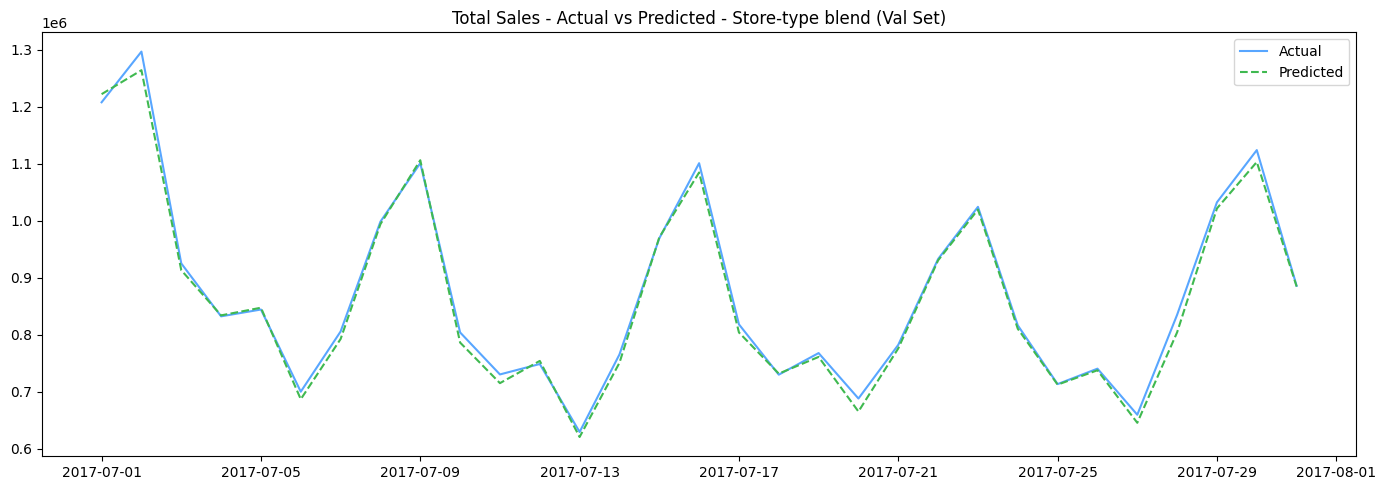

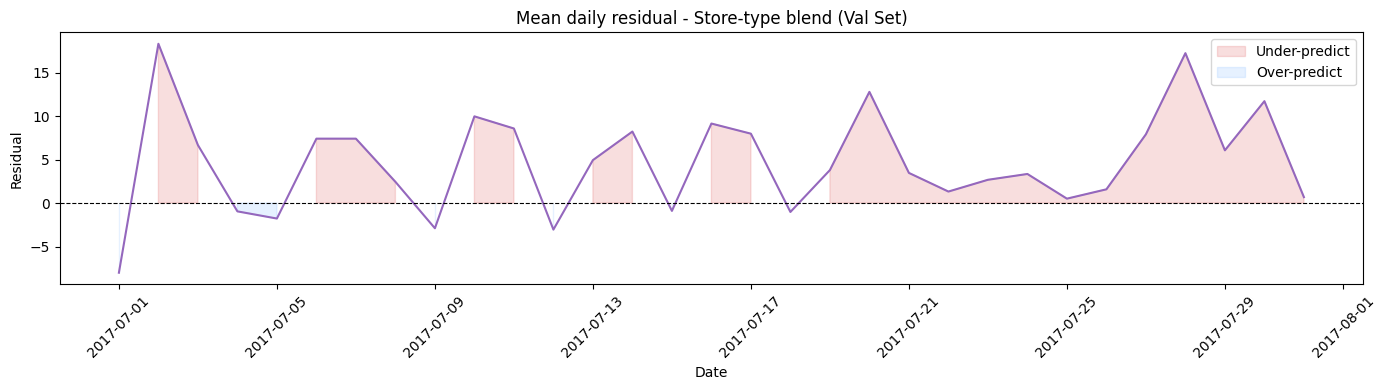

In [6]:
date_val = pd.to_datetime(X_val_raw[["year", "month", "day"]])

blend_val_df = pd.DataFrame(
    {
        "date": date_val.values,
        "actual": y_val_orig["sales"].values,
        "predicted": np.maximum(np.expm1(store_val_blend), 0),
    }
)
blend_val_df["residual"] = blend_val_df["actual"] - blend_val_df["predicted"]

daily_val = blend_val_df[["date", "actual", "predicted"]].groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_val.index, daily_val["actual"], label="Actual", color="#58a6ff")
plt.plot(daily_val.index, daily_val["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title("Total Sales - Actual vs Predicted - Store-type blend (Val Set)")
plt.legend()
plt.tight_layout()
plt.show()

daily_resid_val = blend_val_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid_val.index, daily_resid_val.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(
    daily_resid_val.index,
    daily_resid_val.values,
    0,
    where=daily_resid_val.values > 0,
    alpha=0.15,
    color="#d62728",
    label="Under-predict",
)
ax.fill_between(
    daily_resid_val.index,
    daily_resid_val.values,
    0,
    where=daily_resid_val.values < 0,
    alpha=0.15,
    color="#58a6ff",
    label="Over-predict",
)
ax.set_title("Mean daily residual - Store-type blend (Val Set)")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


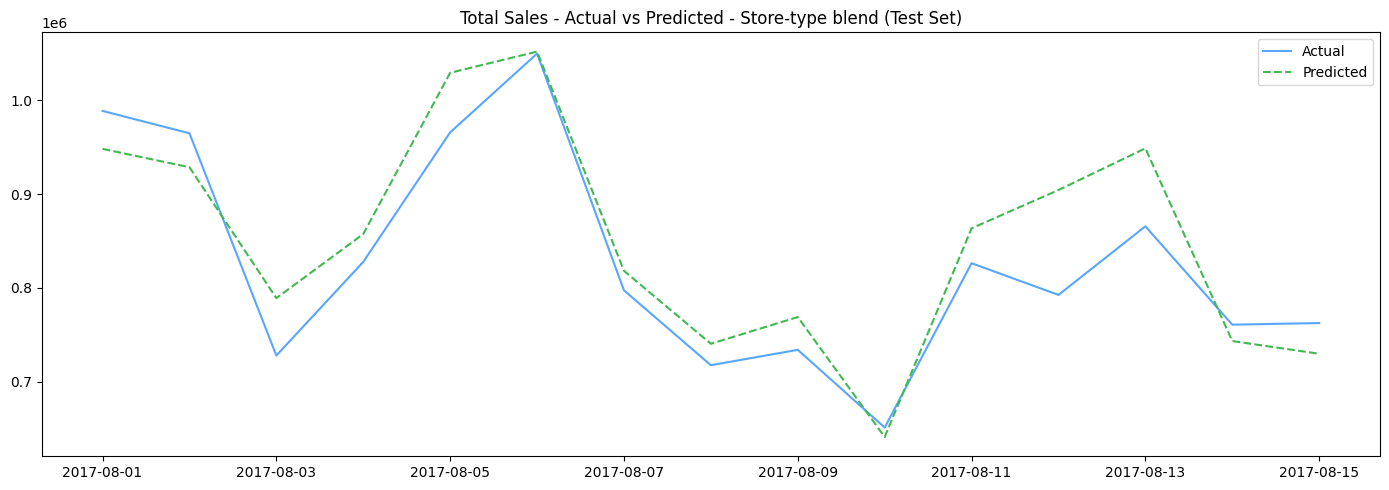

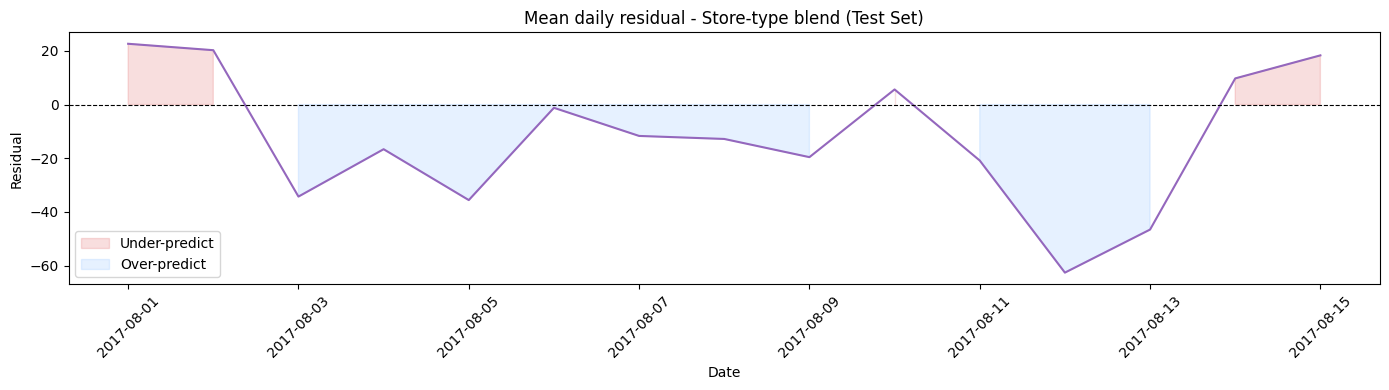

In [7]:
date_test = pd.to_datetime(X_test_raw[["year", "month", "day"]])

blend_test_df = pd.DataFrame(
    {
        "date": date_test.values,
        "actual": y_test_orig["sales"].values,
        "predicted": np.maximum(np.expm1(store_test_blend), 0),
    }
)
blend_test_df["residual"] = blend_test_df["actual"] - blend_test_df["predicted"]

daily_test = blend_test_df[["date", "actual", "predicted"]].groupby("date").sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_test.index, daily_test["actual"], label="Actual", color="#58a6ff")
plt.plot(daily_test.index, daily_test["predicted"], label="Predicted", color="#3fb950", linestyle="--")
plt.title("Total Sales - Actual vs Predicted - Store-type blend (Test Set)")
plt.legend()
plt.tight_layout()
plt.show()

daily_resid_test = blend_test_df.groupby("date")["residual"].mean()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily_resid_test.index, daily_resid_test.values, color="#9467bd", linewidth=1.5)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.fill_between(
    daily_resid_test.index,
    daily_resid_test.values,
    0,
    where=daily_resid_test.values > 0,
    alpha=0.15,
    color="#d62728",
    label="Under-predict",
)
ax.fill_between(
    daily_resid_test.index,
    daily_resid_test.values,
    0,
    where=daily_resid_test.values < 0,
    alpha=0.15,
    color="#58a6ff",
    label="Over-predict",
)
ax.set_title("Mean daily residual - Store-type blend (Test Set)")
ax.set_xlabel("Date")
ax.set_ylabel("Residual")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [8]:
store_type_metrics = []
for store_type in sorted(val_store_type.unique()):
    mask = val_store_type == store_type
    store_type_metrics.append(
        {
            "store_type": store_type,
            "rows": int(mask.sum()),
            "lgb_rmsle": round(rmsle_from_log(y_val_orig.loc[mask, "sales"], lgb_val_pred[mask]), 6),
            "xgb_rmsle": round(rmsle_from_log(y_val_orig.loc[mask, "sales"], xgb_val_pred[mask]), 6),
            "store_blend_rmsle": round(rmsle_from_log(y_val_orig.loc[mask, "sales"], store_val_blend[mask]), 6),
        }
    )

store_type_metrics_df = pd.DataFrame(store_type_metrics).sort_values("store_blend_rmsle", ascending=False)
print("Validation performance by store type")
print(store_type_metrics_df.to_string(index=False, float_format="{:.6f}".format))


Validation performance by store type
store_type  rows  lgb_rmsle  xgb_rmsle  store_blend_rmsle
         C 15345   0.390665   0.363628           0.363628
         E  4092   0.381969   0.355744           0.355744
         B  8184   0.368866   0.346872           0.346872
         D 18414   0.329045   0.310764           0.310764
         A  9207   0.306154   0.286068           0.286068


In [9]:
top_under_dates = (
    blend_test_df.groupby("date")["residual"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .rename("mean_residual")
)
print("Top under-predicted dates")
print(top_under_dates.to_string(float_format="{:.2f}".format))


Top under-predicted dates
date
2017-08-01    22.69
2017-08-02    20.29
2017-08-15    18.36
2017-08-14     9.77
2017-08-10     5.65
2017-08-06    -1.19
2017-08-07   -11.68
2017-08-08   -12.81
2017-08-04   -16.63
2017-08-09   -19.59


In [10]:
top_over_dates = (
    blend_test_df.groupby("date")["residual"]
    .mean()
    .sort_values(ascending=True)
    .head(10)
    .rename("mean_residual")
)
print("Top over-predicted dates")
print(top_over_dates.to_string(float_format="{:.2f}".format))


Top over-predicted dates
date
2017-08-12   -62.66
2017-08-13   -46.60
2017-08-05   -35.60
2017-08-03   -34.30
2017-08-11   -20.85
2017-08-09   -19.59
2017-08-04   -16.63
2017-08-08   -12.81
2017-08-07   -11.68
2017-08-06    -1.19
